In [45]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import unicodedata

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [46]:
# Estrutura padrão do projeto
RAIZ = Path(".")
PASTAS = [
"dados_brutos", "dados_tratados",
"notebooks", "sql", "dashboards", "relatorios", "apresentacao", "logs"]
for pasta in PASTAS:
  (RAIZ / pasta).mkdir(
  parents=True, exist_ok=True)
  print("Pastas verificadas/criadas:")
for pasta in PASTAS:
  print("-", RAIZ / pasta)

Pastas verificadas/criadas:
Pastas verificadas/criadas:
Pastas verificadas/criadas:
Pastas verificadas/criadas:
Pastas verificadas/criadas:
Pastas verificadas/criadas:
Pastas verificadas/criadas:
Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notebooks
- sql
- dashboards
- relatorios
- apresentacao
- logs


In [47]:
# Parâmetros
ARQUIVO_BRUTO = Path(
"dados_abertos_prf-datatran2025.csv")
ARQUIVO_BASE_ANALITICA = Path(
"dados_tratados/base_analitica_prf_2025.csv")
ARQUIVO_BASE_MODELAVEL = Path(
"dados_tratados/base_modelavel_prf_2025.csv")
ARQUIVO_DICIONARIO = Path(
"dados_tratados/dicionario_variaveis_modulo4.csv")
ARQUIVO_DECISOES = Path(
"logs/decisoes_tratamento_modulo4.md")
ARQUIVO_README = Path("README.md")

SEPARADOR = ";"
ENCODING_ENTRADA = "latin1"
ENCODING_SAIDA = "utf-8-sig"

In [48]:
# Lenda CSV com Fallback de Encoding
def ler_csv_prf(caminho, sep=";",encodings=("latin1","utf-8","utf-8-sig")):
  ultimo_erro = None
  for enc in encodings:
    try:
      print(f"Tentando encoding={enc}...")
      return pd.read_csv(
          caminho, sep=sep,
          encoding=enc,
          low_memory=False
          )
    except Exception as erro:
      ultimo_erro = erro
      print(f"Falhou com {enc}: {erro}")
  raise ultimo_erro


df = ler_csv_prf(ARQUIVO_BRUTO, sep=SEPARADOR)
df.head(10)

Tentando encoding=latin1...


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG
5,652569,2025-01-01,quarta-feira,10:40:00,MT,70,669,CACERES,Transitar na contramão,Colisão frontal,Com Vítimas Fatais,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,4,2,0,0,1,2,0,5,"-16,04148578","-57,25884017",SPRF-MT,DEL03-MT,UOP02-DEL03-MT
6,652573,2025-01-01,quarta-feira,12:23:00,RS,116,376,TAPES,Ausência de reação do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Reta,Não,2,0,1,0,0,1,1,2,"-30,739714","-51,62594",SPRF-RS,DEL02-RS,UOP02-DEL02-RS
7,652617,2025-01-01,quarta-feira,17:45:00,SC,101,"207,4",SAO JOSE,Ausência de reação do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Nublado,Dupla,Reta,Sim,2,0,1,0,1,0,1,2,"-27,60001226","-48,6226467",SPRF-SC,DEL01-SC,UOP01-DEL01-SC
8,652625,2025-01-01,quarta-feira,18:40:00,MG,116,"708,5",MURIAE,Velocidade Incompatível,Tombamento,Com Vítimas Fatais,Anoitecer,Crescente,Nublado,Simples,Curva,Não,2,1,0,0,0,1,0,2,"-21,16328873","-42,37968988",SPRF-MG,DEL07-MG,UOP02-DEL07-MG
9,652648,2025-01-01,quarta-feira,17:00:00,PE,407,"7,4",AFRANIO,Demais falhas mecânicas ou elétricas,Incêndio,Sem Vítimas,Pleno dia,Crescente,Céu Claro,Simples,Aclive;Curva,Não,2,0,0,0,2,0,0,1,"-8,47503105","-41,0137105",SPRF-PE,DEL06-PE,UOP02-DEL06-PE


In [49]:
# Padronização das Colunas
def normalizar_nome_coluna(nome):
  nome = str(nome).strip().lower()
  nome = unicodedata.normalize("NFKD", nome).encode("ascii","ignore").decode("utf-8")
  nome = nome.replace(" ","_").replace("-","_").replace("/","_")
  while " " in nome:
    nome = nome.replace(" ","_")
  return nome.strip("_")

df.columns = [normalizar_nome_coluna(c)for c in df.columns]


renomear = {
    "condicao_meteorologica":
    "condicao_metereologica"
    }
df = df.rename(
    columns={
    k:v for k,v in renomear.items() if k in df.columns
    })

In [50]:
# Conferindo Colunas
colunas_esperadas = [
    "data_inversa",
    "dia_semana",
    "horario",
    "uf",
    "br",
    "municipio",
    "causa_acidente",
    "tipo_acidente",
    "classificacao_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "feridos",
    "veiculos"
    ]

faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas faltantes:", faltantes)

if faltantes:
  print("Atenção: ajuste nomes ou " " confirme o dicionário da PRF.")

Colunas faltantes: []


In [51]:
# Tipos de dados e memória utilizada
df.info(memory_usage="deep")

resumo_tipos = (
  df.dtypes.astype(str)
  .value_counts()
  .rename_axis("tipo")
  .reset_index(name="qtd_colunas")
)

display(resumo_tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,tipo,qtd_colunas
0,object,20
1,int64,10


In [52]:
# Diagnóstico de valores ausentes
nulos = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values(
  "perc_nulos", ascending=False
  )
display(nulos[nulos["qtd_nulos"] > 0])

,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


In [53]:
# Diagnóstico e remoção de duplicidades

qtd_duplicadas = df.duplicated().sum()
print("Duplicidades exatas:", qtd_duplicadas)
if qtd_duplicadas > 0:
  df = df.drop_duplicates().copy()
print("Duplicidades removidas.")
print("Nova dimensão:", df.shape)

Duplicidades exatas: 0
Duplicidades removidas.
Nova dimensão: (72529, 30)


In [54]:
# Cardinalidade das variáveis categóricas
categoricas = df.select_dtypes( include="object").columns

cardinalidade = (
  df[categoricas]
  .nunique(dropna=True)
  .sort_values(ascending=False)
  .reset_index()
  )
cardinalidade.columns = [ "variavel","qtd_categorias"]
display(cardinalidade.head(30))

,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


In [55]:
# Convertendo em Colunas Numéricas
colunas_numericas = [
    "br",
    "km",
    "pessoas",
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "ilesos",
    "ignorados",
    "veiculos"
  ]

for coluna in colunas_numericas:
  if coluna in df.columns:
    df[coluna] = pd.to_numeric( df[coluna], errors="coerce")

print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


In [56]:
# Variaveis Temporais e Tratamento de Datas
df["data_inversa"] = pd.to_datetime(
df["data_inversa"], errors="coerce")

df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin( [5,6]).astype(int)

In [57]:
# Tratando Horario e Criando Turno
horario_limpo = df["horario"].astype(str).str.strip()
df["hora"] = pd.to_datetime(
horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour

def classificar_turno(hora):
  if pd.isna(hora): return "IGNORADO"
  if 0 <= hora <= 5: return "MADRUGADA"
  if 6 <= hora <= 11: return "MANHA"
  if 12 <= hora <= 17: return "TARDE"
  return "NOITE"

df["turno"] = df["hora"].apply( classificar_turno)

In [58]:
# Criando Faixa Horaria
def criar_faixa_horaria(hora):
  if pd.isna(hora):
    return "IGNORADO"

  inicio = int(hora // 3) * 3
  fim = inicio + 2

  return f"{inicio:02d}h-{fim:02d}h"

df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)

display( df["faixa_horaria"]
.value_counts(dropna=False)
.sort_index())

faixa_horaria
00h-02h     3959
03h-05h     4948
06h-08h    11517
09h-11h     9342
12h-14h     9678
15h-17h    12624
18h-20h    13473
21h-23h     6988
Name: count, dtype: int64

In [59]:
# Padronizando Textos
colunas_texto = df.select_dtypes(include="object").columns

for coluna in colunas_texto:
  df[coluna] = (
      df[coluna]
      .astype("string")
      .str.strip()
      .str.upper()
      )
  df[coluna] = df[coluna].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})
print("Colunas textuais padronizadas:", len(colunas_texto))

Colunas textuais padronizadas: 20


In [60]:
# Tratando Nulos Categóricos
categoricas_importantes = [
    "uf",
    "municipio",
    "causa_acidente",
    "tipo_acidente",
    "fase_dia",
    "condicao_metereologica",
    "tipo_pista",
    "tracado_via",
    "uso_solo",
    "classificacao_acidente",
    "dia_semana"
    ]
for coluna in categoricas_importantes:
  if coluna in df.columns:
    df[coluna] = df[coluna].fillna( "IGNORADO")

print(df[categoricas_importantes].isna().sum().sort_values(ascending=False))

uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64


In [61]:
# Tratando Nulos Numericos de Contagem
contagens_vitimas = [
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "pessoas",
    "veiculos"
    ]
for coluna in contagens_vitimas:
  if coluna in df.columns:
    df[coluna] = df[coluna].fillna(0)
print(df[[c for c in contagens_vitimas  if c in df.columns]].isna().sum())

mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64


In [62]:
# Criando Variável-Alvo: Acidente Fatal
df["acidente_fatal"] = np.where(df["mortos"] > 1, 1, 0)

validacao_alvo = df["acidente_fatal"].value_counts(dropna=False).rename_axis("acidente_fatal").reset_index(name="qtd")
validacao_alvo["perc"] = validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100
display(validacao_alvo)

,acidente_fatal,qtd,perc
0,0,71951,99.203077
1,1,578,0.796923


In [63]:
# Validar logicamente o alvo
validacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] >= 0) & (df["acidente_fatal"] != 0))
]

print("Violações de regra de alvo:", len(validacoes))

Violações de regra de alvo: 5210


In [64]:
# Criando Indicadres de Gravidade
df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
df["acidente_grave"] = np.where(
  (df["mortos"] >= 1) | (df["feridos_graves"] >= 1),
  1,
  0
)

df["indice_gravidade"] = (
    df["mortos"] * 3
    + df["feridos_graves"] * 2
    + df["feridos_leves"]
  )

display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas", "indice_gravidade"]].head())

,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade
0,0,1,0,1,1
1,1,1,0,2,4
2,0,3,0,3,3
3,0,1,0,1,1
4,0,1,1,2,3


In [65]:
# Criando BR formatada e Chave de Localidade
def formatar_br(valor):
  if pd.isna(valor) or valor == 0:
    return "BR-IGNORADA"
  return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)

df["chave_localidade"] = (
    df["uf"].astype(str) + "_" +
    df["municipio"].astype(str) + "_" +
    df["br_formatada"].astype(str) + "_"
)

display(df[["uf", "municipio", "br", "br_formatada", "chave_localidade"]].head())

,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_GUARULHOS_BR-116_
1,CE,PENAFORTE,116,BR-116,CE_PENAFORTE_BR-116_
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_CORNELIO PROCOPIO_BR-369_
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116_
4,MG,FRANCISCO SA,251,BR-251,MG_FRANCISCO SA_BR-251_


In [66]:
checagens = {
    "linhas": len(df),
    "colunas": df.shape[1],
    "acidentes_fatais": int(
        df["acidente_fatal"].sum()
    ),
    "taxa_fatalidade": float(
        df["acidente_fatal"].mean()
    ),
    "total_mortos": int(
        df["mortos"].sum()
    ),
    "total_feridos": int(
        df["feridos"].sum()
    ) if "feridos" in df.columns else None,
}

checagens

{'linhas': 72529,
 'colunas': 44,
 'acidentes_fatais': 578,
 'taxa_fatalidade': 0.007969226102662383,
 'total_mortos': 6043,
 'total_feridos': 83550}

In [67]:
# Ranking de Categorias
def ranking_categoria(base, coluna, n=20):
    return (
        base[coluna]
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(coluna)
        .reset_index(name="qtd")
    )


display(
    ranking_categoria(
        df,
        "causa_acidente",
        20
    )
)

display(
    ranking_categoria(
        df,
        "tipo_acidente",
        20
    )
)

,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


In [68]:
# Taxa de Fatalidade por Categoria

def taxa_fatal_por_categoria(
    base,
    coluna,
    min_registros=20
):
    tab = base.groupby(coluna).agg(
        qtd_acidentes=("acidente_fatal", "size"),
        qtd_fatais=("acidente_fatal", "sum"),
        taxa_fatal=("acidente_fatal", "mean")
    ).reset_index()

    tab = tab[
        tab["qtd_acidentes"] >= min_registros
    ]

    return tab.sort_values(
        "taxa_fatal",
        ascending=False
    )


display(
    taxa_fatal_por_categoria(
        df,
        "tipo_acidente",
        min_registros=20
    ).head(10)
)

,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
4,COLISÃO FRONTAL,4739,306,0.064571
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,32,0.014870
2,CAPOTAMENTO,1373,10,0.007283
14,SAÍDA DE LEITO CARROÇÁVEL,10209,57,0.005583
1,ATROPELAMENTO DE PEDESTRE,3057,17,0.005561
0,ATROPELAMENTO DE ANIMAL,1133,6,0.005296
7,COLISÃO TRANSVERSAL,9306,41,0.004406
3,COLISÃO COM OBJETO,5109,18,0.003523
11,EVENTOS ATÍPICOS,287,1,0.003484
16,TOMBAMENTO,6351,22,0.003464


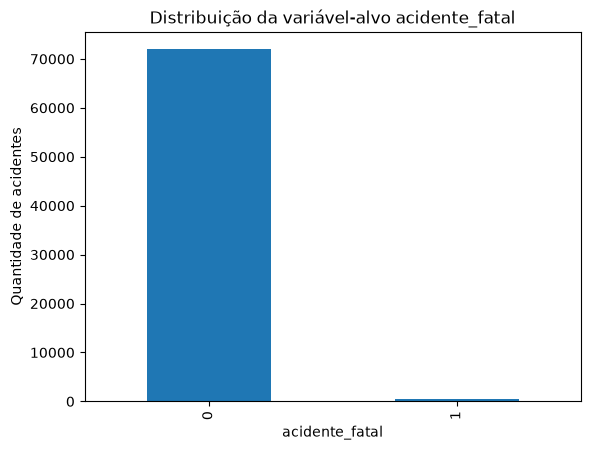

In [69]:
# Gráfico do Alvo
ax = (
    df["acidente_fatal"]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

ax.set_title(
    "Distribuição da variável-alvo acidente_fatal"
)

ax.set_xlabel("acidente_fatal")
ax.set_ylabel("Quantidade de acidentes")

plt.show()

In [70]:
# Criando Base Analítica
base_analitica = df.copy()

print(
    "Base analítica:",
    base_analitica.shape
)

print(
    "Colunas:",
    base_analitica.columns.tolist()
)

Base analítica: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'total_vitimas', 'acidente_grave', 'indice_gravidade', 'br_formatada', 'chave_localidade']


In [71]:
# Selecionando Variáveis Modeláveis
variaveis_modelaveis = [
    "uf", "br_formatada", "municipio",
    "mes", "trimestre",
    "dia_semana", "dia_semana_num",
    "fim_de_semana",
    "hora", "faixa_horaria",
    "turno", "fase_dia",
    "causa_acidente", "tipo_acidente",
    "condicao_metereologica",
    "tipo_pista", "tracado_via",
    "uso_solo", "acidente_fatal"
]

variaveis_modelaveis = [
    c for c in variaveis_modelaveis
    if c in df.columns
]

base_modelavel = df[
    variaveis_modelaveis
].copy()

print(
    "Base modelável:",
    base_modelavel.shape
)

Base modelável: (72529, 19)


In [72]:
# Verificação de Data Leakage
variaveis_proibidas = [
    "mortos",
    "feridos",
    "feridos_leves",
    "feridos_graves",
    "total_vitimas",
    "indice_gravidade",
    "acidente_grave",
    "classificacao_acidente"
]


def verificar_data_leakage(
    base,
    proibidas
):
    presentes = [
        c for c in proibidas
        if c in base.columns
    ]

    if presentes:
        raise ValueError(
            f"Data leakage detectado: {presentes}"
        )

    return "OK — nenhuma variável proibida encontrada."


verificar_data_leakage(
    base_modelavel,
    variaveis_proibidas
)

'OK — nenhuma variável proibida encontrada.'

In [73]:
# Tratamento Final de Variáveis Nulas
for coluna in base_modelavel.columns:

    if coluna == "acidente_fatal":
        continue

    if (
        base_modelavel[coluna].dtype == "object"
        or str(base_modelavel[coluna].dtype) == "string"
    ):
        base_modelavel[coluna] = (
            base_modelavel[coluna]
            .fillna("IGNORADO")
        )
    else:
        base_modelavel[coluna] = (
            base_modelavel[coluna]
            .fillna(-1)
        )


print(
    base_modelavel
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head()
)

uf              0
br_formatada    0
municipio       0
mes             0
trimestre       0
dtype: int64


In [74]:
# Explorando Bases
base_analitica.to_csv(
    ARQUIVO_BASE_ANALITICA,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

base_modelavel.to_csv(
    ARQUIVO_BASE_MODELAVEL,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

Arquivos exportados:
- dados_tratados\base_analitica_prf_2025.csv
- dados_tratados\base_modelavel_prf_2025.csv


In [75]:
# Reabrir e Validando
valid_analitica = pd.read_csv(
    ARQUIVO_BASE_ANALITICA,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

valid_modelavel = pd.read_csv(
    ARQUIVO_BASE_MODELAVEL,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

print(
    "Analítica reaberta:",
    valid_analitica.shape
)

print(
    "Modelável reaberta:",
    valid_modelavel.shape
)

assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)

Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)


In [76]:
# Dicionário de Variáveis
linhas_dic = [
    {
        "variavel": "acidente_fatal",
        "descricao": "1 se mortos >= 1; 0 se mortos = 0",
        "uso": "alvo"
    },
    {
        "variavel": "total_vitimas",
        "descricao": "mortos + feridos leves + feridos graves",
        "uso": "analise/dashboard"
    },
    {
        "variavel": "indice_gravidade",
        "descricao": "mortos*3 + feridos_graves*2 + feridos_leves",
        "uso": "analise/dashboard"
    },
    {
        "variavel": "br_formatada",
        "descricao": "BR padronizada no formato BR-000",
        "uso": "analise/modelagem"
    },
    {
        "variavel": "chave_localidade",
        "descricao": "UF + município + BR formatada",
        "uso": "analise/dashboard"
    },
]

dicionario = pd.DataFrame(linhas_dic)

dicionario.to_csv(
    ARQUIVO_DICIONARIO,
    index=False,
    sep=SEPARADOR,
    encoding=ENCODING_SAIDA
)

display(dicionario)

,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR-000,analise/modelagem
4,chave_localidade,UF + município + BR formatada,analise/dashboard


In [77]:
# Registrando Deciões
texto_decisoes = f"""
# Decisões de tratamento — Módulo 4

Data de geração: {
    datetime.now().strftime('%Y-%m-%d %H:%M')
}

## Principais decisões

- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.

## Arquivos gerados

- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""

ARQUIVO_DECISOES.write_text(
    texto_decisoes,
    encoding="utf-8"
)

print(ARQUIVO_DECISOES)

logs\decisoes_tratamento_modulo4.md


In [78]:
# Criando README
readme = f"""
# Projeto PRF 2025 — Preparação dos Dados

## Objetivo

Preparar os dados de acidentes da PRF 2025 para análise exploratória,
Power BI e árvore de decisão explicável.

## Variável-alvo

`acidente_fatal = 1` quando `mortos >= 1`;
caso contrário, `acidente_fatal = 0`.

## Bases geradas

- `{ARQUIVO_BASE_ANALITICA}`: base completa para EDA e Power BI.
- `{ARQUIVO_BASE_MODELAVEL}`: base para modelagem, sem data leakage.

## Observação metodológica

A base modelável exclui mortos, feridos,
total_vitimas, indice_gravidade e variáveis
diretamente derivadas do desfecho.
"""

ARQUIVO_README.write_text(
    readme,
    encoding="utf-8"
)

print(
    "README criado:",
    ARQUIVO_README
)

README criado: README.md


In [79]:
# Resumo Final
resumo_final = pd.DataFrame([
    {
        "item": "linhas_base_analitica",
        "valor": len(base_analitica)
    },
    {
        "item": "colunas_base_analitica",
        "valor": base_analitica.shape[1]
    },
    {
        "item": "linhas_base_modelavel",
        "valor": len(base_modelavel)
    },
    {
        "item": "colunas_base_modelavel",
        "valor": base_modelavel.shape[1]
    },
    {
        "item": "taxa_global_acidente_fatal",
        "valor": base_modelavel[
            "acidente_fatal"
        ].mean()
    },
])

display(resumo_final)

,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,taxa_global_acidente_fatal,0.007969
